In [1]:
# Import module constrained_likelihood_surrogates
#
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

In [2]:
line_style_list = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']
col_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
marker_list = ['s', 'd', 'o', '|', '_', '+', 'x', '1', '2', '3', '4', '*', '8', 'p']

load_folder_name = './results/hyp-test/fires/'

process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
method_list = ['constrained', 'typical', 'sign', 'CLT']
num_methods = len(method_list)

In [3]:
# Load fire data:
# Data in year X correspond to all fires that happened between July in the year X and June in the year X+1.
# (Data for 2000 shorter because they start from November)
year = 2019
fire_seq = np.load('../data/fires/fireSize-' + str(year) + '.npy', 'r')
fire_seq = [int(np.round(val)) for val in fire_seq]

In [4]:
# Select results to plot:

# Figures 6 and S8: lognormal, xmin=32.5
est_save_str = 'statistics_nsur-100000_ntyp-4_nmod-2_9Ns-475-4_nstats-12_fires_year-2019_lower-cutoff-type-32.5_above-xmin-only'
hyp_save_str = 'quant_free-depe_rejection_xmin-32.5_N-475_ntra-9025_nsur-99_ntes-1000_ntyp-2_nmod-2_nfs-12_nds-7_fires-2019'
i_model = 1#lognormal

# # Figure S9: powerlaw, xmin=40.5
# est_save_str = 'statistics_nsur-100000_ntyp-4_nmod-2_9Ns-417-4_nstats-12_fires_year-2019_lower-cutoff-type-40.5_above-xmin-only'
# hyp_save_str = 'quant_free-depe_rejection_xmin-40.5_N-417_ntra-7923_nsur-99_ntes-1000_ntyp-2_nmod-2_nfs-12_nds-7_fires-2019'
# i_model = 0#powerlaw

lower_cutoff_hat=32.5
num_surr_est=100000
num_surr_hyp=99
lognorm


C:\Users\murdo\AppData\Local\Temp\ipykernel_16112\2575464470.py:74: RuntimeWarning: invalid value encountered in sqrt
  bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement
C:\Users\murdo\AppData\Local\Temp\ipykernel_16112\2575464470.py:147: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0, 10*max([density_left[i] for i in range(len(density_left)) if (bin_centres_left[i] > 0)])])


model=lognorm, method=constrained, stat=maximum
model=lognorm, method=typical, stat=KS distance


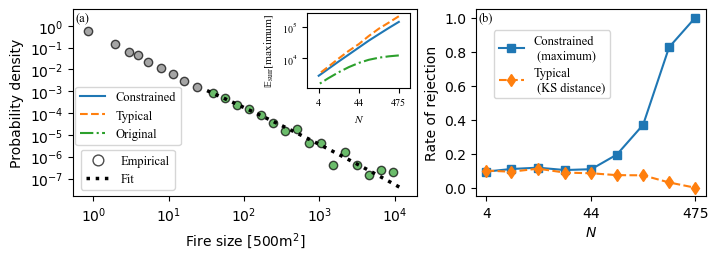

In [5]:
# Code to plot Figure 6:

# Load results: estimation

with open('./results/est-stat/' + est_save_str + '.json', 'r') as read_file:
    save_dict = json.load(read_file)

mean_stat_list_list_list = np.array(save_dict['mean_stat_list_list_list'])# num_null_models x num_methods x num_Ns x num_stats
var_stat_list_list_list = np.array(save_dict['var_stat_list_list_list'])# num_null_models x num_methods x num_Ns x num_stats
val_seq = save_dict['val_seq']
test_type = save_dict['test_type']
lower_cutoff_type = save_dict['lower_cutoff_type']
lower_cutoff_hat = save_dict['lower_cutoff_hat']
N = save_dict['N']
Ns_list = save_dict['Ns_list']
num_trans_list = save_dict['num_trans_list']
num_surr = save_dict['num_surr']
method_list = save_dict['method_list']
num_methods = save_dict['num_methods']
null_model_list = save_dict['null_model_list']
data_str = save_dict['data_str']
k_null_list = save_dict['k_null_list']
NLL_list = save_dict['NLL_list']
BIC_list = save_dict['BIC_list']
AIC_list = save_dict['AIC_list']
param_hat_null_list = save_dict['param_hat_null_list']
save_str = save_dict['save_str']
stat_name_list = save_dict['stat_name_list']
num_stats = save_dict['num_stats']
total_time = save_dict['total_time']

num_surr_est = num_surr
model_list = null_model_list
num_models = len(model_list)
N_list = sorted(Ns_list)

# Load one hypothesis-testing result to obtain saved settings:

load_folder_name = './results/hyp-test/fires/'
with open(load_folder_name + hyp_save_str + '.json', 'r') as read_file:
    save_dict_hyp = json.load(read_file)

if (save_dict_hyp['lower_cutoff'] != lower_cutoff_hat):
    raise Exception('Different lower cutoffs for estimation and hypothesis testing.')

num_surr_hyp = save_dict_hyp['num_surr']

print(f'lower_cutoff_hat={lower_cutoff_hat}')
print(f'num_surr_est={num_surr_est}')
print(f'num_surr_hyp={num_surr_hyp}')

fig, ax_array = plt.subplots(1, 2, figsize=(7, 2.5), width_ratios=[3, 2])

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

# # Empirical pdf and fit (left panel):

ax = ax_array[0]

val_seq = fire_seq
    
# Calculate num_bin log-spaced bin at "half-integers"
b = 3**(1/3)
log_of_bins_right = np.arange(np.log(lower_cutoff_hat), np.log(np.max(val_seq)) + 0.5*np.log(b), np.log(b))
log_of_bins_left = np.arange(np.log(0.5), np.log(lower_cutoff_hat) + 0.5*np.log(b), np.log(b))

# Define log bins on left
bins_left = np.exp(log_of_bins_left)
bins_left = np.concatenate(([-0.5], bins_left)) #
bins_left = np.round(bins_left - 0.5) + 0.5#Round bins_left to nearest half-integer
bins_left = np.unique(bins_left)
num_bins_left = len(bins_left) - 1
bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement

# Compute histogram counts and bin centres on left
counts_left, _ = np.histogram(val_seq, bins=bins_left)  # counts
density_left, _ = np.histogram(val_seq, bins=bins_left, density=True)  # density normalization

# Define log bins on right
bins_right = np.exp(log_of_bins_right)
bins_right = np.round(bins_right - 0.5) + 0.5#Round bins_right to nearest half-integer
bins_right = np.unique(bins_right)
num_bins_right = len(bins_right) - 1
bin_centres_right = np.sqrt(bins_right[:-1]*bins_right[1:])  # Midpoints for marker placement

# Compute histogram counts and bin centres on right
counts_right, _ = np.histogram(val_seq, bins=bins_right)  # counts
density_right, _ = np.histogram(val_seq, bins=bins_right, density=True)  # density normalization

N_left = sum(counts_left)
N_right = sum(counts_right)
N = N_left + N_right

# Plot with circular markers
ax.scatter([], [], s=60, color='None', edgecolor='k', alpha=0.7, marker='o', label='Empirical')
ax.scatter(bin_centres_left, (N_left/N)*density_left, color='tab:gray', edgecolor='black', alpha=0.7, marker='o')#, label='empirical ($x < x_{\min}$)')
ax.scatter(bin_centres_right, (N_right/N)*density_right, color='tab:green', edgecolor='black', alpha=0.7, marker='o')#, label='empirical ($x \geq x_{\min}$)')

lower_cutoff_hat = lower_cutoff_hat
val_seq_right = [val for val in val_seq if (val >= lower_cutoff_hat)]

# i_model = 0#powerlaw
# i_model = 1#lognormal

model = model_list[i_model]
param_hat, lp_seq = fit_model(val_seq_right, model=model, lower_cutoff_hat=lower_cutoff_hat)
print(model)

if (model == 'powerlaw'):
    lambda_hat = param_hat[0]
    fit_pdf_fun = lambda seq : expon.pdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)/seq
elif (model == 'lognorm'):#Truncated lognormal distribution
    if (not np.isinf(param_hat[1])):#Could fit lognormal using maximum likelihood
        mu_hat, sigma_hat = param_hat[0], param_hat[1]
        fit_pdf_fun = lambda seq : truncnorm.pdf(np.log(seq), (np.log(lower_cutoff_hat) - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat, loc=mu_hat, scale=sigma_hat)/seq
    else:#Could not fit lognormal using maximum likelihood: consider powerlaw instead
        lambda_hat = param_hat[0]
        fit_pdf_fun = lambda seq : expon.pdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)/seq
elif (model == 'expon'):#Exponential distribution
    lambda_hat = param_hat[0]
    fit_pdf_fun = lambda seq : expon.pdf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
elif (model == 'truncnorm'):#Truncated Gaussian distribution
    if (not np.isinf(param_hat[1])):#Could fit truncated normal using maximum likelihood
        mu_hat, sigma_hat = param_hat[0], param_hat[1]
        # mu_hat, sigma_hat = np.mean(val_seq_right), np.std(val_seq_right)
        fit_pdf_fun = lambda seq : truncnorm.pdf(seq, (lower_cutoff_hat - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat, loc=mu_hat, scale=sigma_hat)
    else:#Could not fit truncated normal using maximum likelihood: consider exponential instead
        lambda_hat = param_hat[0]
        fit_pdf_fun = lambda seq : expon.pdf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
elif (model == 'uniform'):#Uniform distribution
    b_hat = param_hat[0]
    a = lower_cutoff_hat
    fit_pdf_fun = lambda seq : uniform.pdf(seq, loc=a, scale=(b_hat - a))
else:
    raise Exception('model=' + str(model) + ' not recognised.')

x = np.concatenate(([lower_cutoff_hat], bin_centres_right, [max(val_seq)]))
fit_pdf = fit_pdf_fun(x)

ax.plot(x, N_right/N*fit_pdf, color='k', linestyle=':', label='Fit', linewidth=2.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Probability density')
ax.set_xlabel('Fire size [$500\\text{m}^2$]')
ax.set_ylim([0, 10*max([density_left[i] for i in range(len(density_left)) if (bin_centres_left[i] > 0)])])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# ax.legend(loc='upper right')
# leg1 = ax.legend(loc='lower center', bbox_to_anchor=(0.55, 0))
leg1 = ax.legend(loc='lower center', bbox_to_anchor=(0.16, 0))
# fig.tight_layout(pad=1)
ax.add_artist(leg1)

add_panel_label(ax, '(a)', corner='upper left', offset='auto')



# # Estimation (inset of left panel):

inset_width = 0.30
inset_height = 0.40
ax = ax.inset_axes([1 - (inset_width + 0.02), 1 - (inset_height + 0.02), inset_width, inset_height])

stat_list = [mean_val, second_mom, third_mom, fourth_mom, max_val, variance, coef_var, dispersion, skew, kurtosis, evi_mom, evi_smooth]
stat_full_name_list = ['mean', 'second moment', 'third moment', 'fourth moment', 'max.', 'variance', 'coeff. var.', 'dispersion', 'skewness', 'kurtosis', 'EVI (moment)', 'EVI (smooth)']

i_method_list = [0, 1, 2]#[constrained, typical, original]
# i_method_list = [0, 1, 3]#[constrained, typical, bootstrap]
# i_method_list = [0, 1, 2, 3]#[constrained, typical, original, bootstrap]

x_ticks = [Ns_list[ind] for ind in [0, 4, 8]]

i_stat = 4#'max.'
stat_name = stat_name_list[i_stat]
full_stat_name = 'maximum'

if (model == 'powerlaw') or (model == 'lognorm'):
    ax.set_yscale('log')
    if (model == 'powerlaw'):
        ax.set_yticks([10**0, 10**2, 10**4, 10**6])
    elif (model == 'lognorm'):
        y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
        # y_ticks = [10**0, 3*10**0, 10**1, 3*10**1, 10**2, 3*10**2, 10**3, 3*10**3, 10**4, 3*10**4, 10**5, 3*10**5, 10**6, 3*10**6, 10**7, 3*10**7, 10**8, 3*10**8]
        ax.set_yticks(y_ticks)
        # ax.set_yticklabels(y_ticks)
elif (model == 'expon'):
        ax.set_yticks([0, 5000, 10000, 15000, 20000, 25000, 30000])
else:
    ax.set_yscale('linear')
ax.set_xscale('log')
ax.yaxis.set_minor_locator(NullLocator())
for i_method in i_method_list:
    method = method_list[i_method]
    method_name = beautify_method_name(method)
    mean_stat_list = mean_stat_list_list_list[i_model, i_method, :, i_stat]# num_Ns
    var_stat_list = var_stat_list_list_list[i_model, i_method, :, i_stat]# num_Ns
    std_stat_list = np.sqrt(var_stat_list)# num_Ns
    std_stat_list = std_stat_list
    ax.plot(Ns_list, mean_stat_list, color=col_list[i_method], linestyle=line_style_list[i_method], label=method_name)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)
ax.xaxis.set_minor_locator(NullLocator())
ax.set_xlim([min(Ns_list)/2, max(Ns_list)*2])
ax.set_ylabel('$\\rm\\mathbb{E}_{\\rm{surr}}[$' + full_stat_name + '$]$')
ax.set_xlabel('$N$', x=0.5)

set_inset_fonts(ax)

# # Empirical pdf and fit (left panel, not inset):
ax = ax_array[0]

#Method (e.g., constrained, typical, observed) plot markers:
line_list_2 = []
label_list_2 = []
#Method (e.g., constrained, typical, observed) plot markers:
for i_method in [0, 1, 2]:#['const.', 'typic.', 'sign', 'clt']
    if (i_method == 2):
        method = 'original'
    else:
        method = method_list[i_method]
    method_name = beautify_method_name(method)
    line, = ax.plot([], [], color=col_list[i_method], linestyle=line_style_list[i_method], marker='None', label=method_name)
    line_list_2.append(line)
    label_list_2.append(line.get_label())

#Method (e.g., constrained, typyical, observed) plot markers:
# leg2 = ax.legend(line_list_2, label_list_2, loc='lower center', bbox_to_anchor=(0.42, -0.02))
leg2 = ax.legend(line_list_2, label_list_2, loc='lower center', bbox_to_anchor=(0.16, 0.24))
leg2.set_in_layout(False)

fig.tight_layout()


# # Hypothesis testing (right panel):

ax = ax_array[1]

# # Load results: hypothesis testing

test_type = save_dict_hyp['test_type']

num_N = len(N_list)
N_tick_list = [N_list[ind] for ind in [0, 4, 8]]

num_surr = save_dict_hyp['num_surr']
num_tests = save_dict_hyp['num_tests']
method_list = ['constrained', 'typical']
num_methods = save_dict_hyp['num_methods']
model_list = save_dict_hyp['model_list']
num_models = len(model_list)
free_stat_name_list = save_dict_hyp['free_stat_name_list']
depe_stat_name_list = save_dict_hyp['depe_stat_name_list']
num_free_stats = len(free_stat_name_list)
num_depe_stats = len(depe_stat_name_list)
process_str = save_dict_hyp['process_str']

free_quantile_mat = np.zeros((num_N, num_methods, num_models, num_tests, num_free_stats))
depe_quantile_mat = np.zeros((num_N, num_methods, num_models, num_tests, num_depe_stats))

for i_N in range(num_N):
    N = N_list[i_N]
    num_trans = N*(int(np.ceil(np.log2(N*1024))))
    save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff_hat) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
    save_str = save_str_0 + process_str
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)

    if (save_dict['lower_cutoff'] != lower_cutoff_hat):
        raise Exception('Different lower cutoffs for estimation and hypothesis testing.')
    
    free_quantile_list_list = np.array(save_dict['free_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_free_stats
    free_quantile_mat[i_N, :, :, :, :] = free_quantile_list_list# num_N x num_methods x num_models x num_tests x num_free_stats
    
    depe_quantile_list_list = np.array(save_dict['depe_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_depe_stats
    depe_quantile_mat[i_N, :, :, :, :] = depe_quantile_list_list# num_N x num_methods x num_models x num_tests x num_depe_stats
    
# N = save_dict['N']
# num_trans = save_dict['num_trans']
# save_str = save_dict['save_str']
# total_time = save_dict['total_time']
# test_type = save_dict['test_type']
# lower_cutoff_hat = save_dict['lower_cutoff_hat']
# num_surr = save_dict['num_surr']
# num_tests = save_dict['num_tests']
# num_methods = save_dict['num_methods']
# process_str = save_dict['process_str']
model_list = save_dict['model_list']
free_stat_name_list = save_dict['free_stat_name_list']
depe_stat_name_list = save_dict['depe_stat_name_list']
# fire_seq = save_dict['fire_seq']
# val_seq_full = save_dict['val_seq_full']

nominal_size = 0.10

kL, kU = binom.interval(0.9, num_tests, nominal_size)
pL, pU = kL/num_tests, kU/num_tests
pL = nominal_size - np.sqrt(nominal_size*(1 - nominal_size)/num_tests)
pU = nominal_size + np.sqrt(nominal_size*(1 - nominal_size)/num_tests)

free_rej_mat = (free_quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_free_stats
free_rej_rate_mat = np.sum(free_rej_mat, axis=3)/num_tests# num_N x num_methods x num_models x num_free_stats
depe_rej_mat = (depe_quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_free_stats
depe_rej_rate_mat = np.sum(depe_rej_mat, axis=3)/num_tests# num_N x num_methods x num_models x num_free_stats

stat_type_list = ['free', 'depe']#KS, maximum
side_list = ['left-tailed', 'right-tailed']#KS, maximum
i_stat_list = [4, 0]#KS, maximum
i_method_list = [0, 1]#typical, constrained

for stat_count in range(len(i_stat_list)):
    i_stat = i_stat_list[stat_count]
    stat_type = stat_type_list[stat_count]
    side = side_list[stat_count]
    i_method = i_method_list[stat_count]

    if (stat_type == 'free'):
        stat_name_list = free_stat_name_list
        quantile_mat = free_quantile_mat
    elif (stat_type == 'depe'):
        stat_name_list = depe_stat_name_list
        quantile_mat = depe_quantile_mat
    num_stats = len(stat_name_list)
    stat_name = stat_name_list[i_stat]
    full_stat_name = beautify_stat_name(stat_name)
    if (stat_type == 'free'):
        full_stat_name = full_stat_name[0].lower() + full_stat_name[1:]#Ensure first character is lowercase
    
    if (side == 'left-tailed'):
        rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_models x num_tests x num_stats
    elif (side == 'right-tailed'):
        rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
    elif (side == 'two-sided'):
        rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
        
    rej_rate_mat = np.sum(rej_mat, axis=3)/num_tests# num_N x num_methodsx num_models x num_free_stats
    std_rej_rate_mat = np.std(rej_mat, axis=3, ddof=0)# num_N x num_methods x num_models x num_free_stats
    
    model = model_list[i_model]
    method = method_list[i_method]
    method_name = beautify_method_name(method)
    rej_rate_list = rej_rate_mat[:, i_method, i_model, i_stat]
    # err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
    err_list = std_rej_rate_mat[:, i_method, i_model, i_stat]/np.sqrt(num_tests)
    # ax.errorbar(N_list, rej_rate_list, err_list, color=col_list[i_method], linestyle=line_style_list[i_method], marker=marker_list[stat_count], label=method_name + '\n (' + full_stat_name + ')')
    ax.plot(N_list, rej_rate_list, color=col_list[i_method], linestyle=line_style_list[i_method], marker=marker_list[stat_count], label=method_name + '\n (' + full_stat_name + ')')
    print(f'model={model}, method={method}, stat={full_stat_name}')
        
ax.set_ylabel('Rate of rejection')
ax.set_xlabel('$N$', x=0.5)
ax.set_xscale('log')
ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(N_tick_list)
ax.set_xticklabels(N_tick_list)
x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
ax.set_xlim(x_lim)
ax.set_ylim([-0.05, 1.05])

#Statistic plot markers:
leg1 = ax.legend(loc='upper left', bbox_to_anchor=(0.05, 0.92))
leg1.set_in_layout(False)

add_panel_label(ax, '(b)', corner='upper left', offset='auto')

fig.tight_layout(pad=0.5)
    
bbox = fig.get_tightbbox(fig.canvas.get_renderer())
scale = fig.get_figwidth()/bbox.width
fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

fig_name_str = 'pdf_estimation_hyp-testing_' + model + '_' + 'fires-2019_xmin-' + str(lower_cutoff_hat) + '_simple'
plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')

plt.show()

lower_cutoff_hat=32.5
num_surr_est=100000
num_surr_hyp=99
lognorm


C:\Users\murdo\AppData\Local\Temp\ipykernel_16112\1184201906.py:74: RuntimeWarning: invalid value encountered in sqrt
  bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement
C:\Users\murdo\AppData\Local\Temp\ipykernel_16112\1184201906.py:147: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0, 10*max([density_left[i] for i in range(len(density_left)) if (bin_centres_left[i] > 0)])])


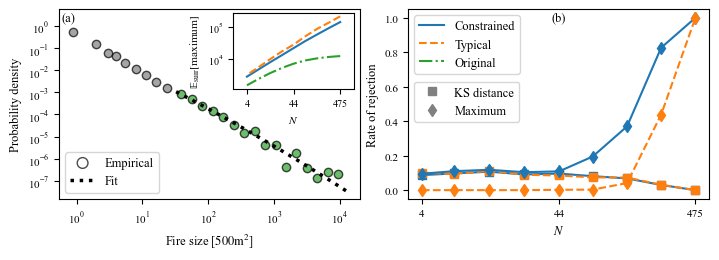

In [6]:
# Code to plot Figure S9, S10:

# Load results: estimation

with open('./results/est-stat/' + est_save_str + '.json', 'r') as read_file:
    save_dict = json.load(read_file)

mean_stat_list_list_list = np.array(save_dict['mean_stat_list_list_list'])# num_null_models x num_methods x num_Ns x num_stats
var_stat_list_list_list = np.array(save_dict['var_stat_list_list_list'])# num_null_models x num_methods x num_Ns x num_stats
val_seq = save_dict['val_seq']
test_type = save_dict['test_type']
lower_cutoff_type = save_dict['lower_cutoff_type']
lower_cutoff_hat = save_dict['lower_cutoff_hat']
N = save_dict['N']
Ns_list = save_dict['Ns_list']
num_trans_list = save_dict['num_trans_list']
num_surr = save_dict['num_surr']
method_list = save_dict['method_list']
num_methods = save_dict['num_methods']
null_model_list = save_dict['null_model_list']
data_str = save_dict['data_str']
k_null_list = save_dict['k_null_list']
NLL_list = save_dict['NLL_list']
BIC_list = save_dict['BIC_list']
AIC_list = save_dict['AIC_list']
param_hat_null_list = save_dict['param_hat_null_list']
save_str = save_dict['save_str']
stat_name_list = save_dict['stat_name_list']
num_stats = save_dict['num_stats']
total_time = save_dict['total_time']

num_surr_est = num_surr
model_list = null_model_list
num_models = len(model_list)
N_list = sorted(Ns_list)

# Load one hypothesis-testing result to obtain saved settings:

load_folder_name = './results/hyp-test/fires/'
with open(load_folder_name + hyp_save_str + '.json', 'r') as read_file:
    save_dict_hyp = json.load(read_file)

if (save_dict_hyp['lower_cutoff'] != lower_cutoff_hat):
    raise Exception('Different lower cutoffs for estimation and hypothesis testing.')

num_surr_hyp = save_dict_hyp['num_surr']

print(f'lower_cutoff_hat={lower_cutoff_hat}')
print(f'num_surr_est={num_surr_est}')
print(f'num_surr_hyp={num_surr_hyp}')

fig, ax_array = plt.subplots(1, 2, figsize=(7, 2.5))

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

# # Empirical pdf and fit (left panel):

ax = ax_array[0]

val_seq = fire_seq
    
# Calculate num_bin log-spaced bin at "half-integers"
b = 3**(1/3)
log_of_bins_right = np.arange(np.log(lower_cutoff_hat), np.log(np.max(val_seq)) + 0.5*np.log(b), np.log(b))
log_of_bins_left = np.arange(np.log(0.5), np.log(lower_cutoff_hat) + 0.5*np.log(b), np.log(b))

# Define log bins on left
bins_left = np.exp(log_of_bins_left)
bins_left = np.concatenate(([-0.5], bins_left)) #
bins_left = np.round(bins_left - 0.5) + 0.5#Round bins_left to nearest half-integer
bins_left = np.unique(bins_left)
num_bins_left = len(bins_left) - 1
bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement

# Compute histogram counts and bin centres on left
counts_left, _ = np.histogram(val_seq, bins=bins_left)  # counts
density_left, _ = np.histogram(val_seq, bins=bins_left, density=True)  # density normalization

# Define log bins on right
bins_right = np.exp(log_of_bins_right)
bins_right = np.round(bins_right - 0.5) + 0.5#Round bins_right to nearest half-integer
bins_right = np.unique(bins_right)
num_bins_right = len(bins_right) - 1
bin_centres_right = np.sqrt(bins_right[:-1]*bins_right[1:])  # Midpoints for marker placement

# Compute histogram counts and bin centres on right
counts_right, _ = np.histogram(val_seq, bins=bins_right)  # counts
density_right, _ = np.histogram(val_seq, bins=bins_right, density=True)  # density normalization

N_left = sum(counts_left)
N_right = sum(counts_right)
N = N_left + N_right

# Plot with circular markers
ax.scatter([], [], s=60, color='None', edgecolor='k', alpha=0.7, marker='o', label='Empirical')
ax.scatter(bin_centres_left, (N_left/N)*density_left, color='tab:gray', edgecolor='black', alpha=0.7, marker='o')#, label='empirical ($x < x_{\min}$)')
ax.scatter(bin_centres_right, (N_right/N)*density_right, color='tab:green', edgecolor='black', alpha=0.7, marker='o')#, label='empirical ($x \geq x_{\min}$)')

lower_cutoff_hat = lower_cutoff_hat
val_seq_right = [val for val in val_seq if (val >= lower_cutoff_hat)]

# i_model = 0#powerlaw
# i_model = 1#lognormal

model = model_list[i_model]
param_hat, lp_seq = fit_model(val_seq_right, model=model, lower_cutoff_hat=lower_cutoff_hat)
print(model)

if (model == 'powerlaw'):
    lambda_hat = param_hat[0]
    fit_pdf_fun = lambda seq : expon.pdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)/seq
elif (model == 'lognorm'):#Truncated lognormal distribution
    if (not np.isinf(param_hat[1])):#Could fit lognormal using maximum likelihood
        mu_hat, sigma_hat = param_hat[0], param_hat[1]
        fit_pdf_fun = lambda seq : truncnorm.pdf(np.log(seq), (np.log(lower_cutoff_hat) - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat, loc=mu_hat, scale=sigma_hat)/seq
    else:#Could not fit lognormal using maximum likelihood: consider powerlaw instead
        lambda_hat = param_hat[0]
        fit_pdf_fun = lambda seq : expon.pdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)/seq
elif (model == 'expon'):#Exponential distribution
    lambda_hat = param_hat[0]
    fit_pdf_fun = lambda seq : expon.pdf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
elif (model == 'truncnorm'):#Truncated Gaussian distribution
    if (not np.isinf(param_hat[1])):#Could fit truncated normal using maximum likelihood
        mu_hat, sigma_hat = param_hat[0], param_hat[1]
        # mu_hat, sigma_hat = np.mean(val_seq_right), np.std(val_seq_right)
        fit_pdf_fun = lambda seq : truncnorm.pdf(seq, (lower_cutoff_hat - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat, loc=mu_hat, scale=sigma_hat)
    else:#Could not fit truncated normal using maximum likelihood: consider exponential instead
        lambda_hat = param_hat[0]
        fit_pdf_fun = lambda seq : expon.pdf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
elif (model == 'uniform'):#Uniform distribution
    b_hat = param_hat[0]
    a = lower_cutoff_hat
    fit_pdf_fun = lambda seq : uniform.pdf(seq, loc=a, scale=(b_hat - a))
else:
    raise Exception('model=' + str(model) + ' not recognised.')

x = np.concatenate(([lower_cutoff_hat], bin_centres_right, [max(val_seq)]))
fit_pdf = fit_pdf_fun(x)

ax.plot(x, N_right/N*fit_pdf, color='k', linestyle=':', label='Fit', linewidth=2.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Probability density')
ax.set_xlabel('Fire size [$500\\text{m}^2$]')
ax.set_ylim([0, 10*max([density_left[i] for i in range(len(density_left)) if (bin_centres_left[i] > 0)])])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# ax.legend(loc='upper right')
ax.legend(loc='lower left')
# fig.tight_layout(pad=1)

add_panel_label(ax, '(a)', corner='upper left', offset='auto')



# # Estimation (inset of left panel):

inset_length = 0.40
ax = ax.inset_axes([1 - (inset_length + 0.02), 1 - (inset_length + 0.02), inset_length, inset_length])

stat_list = [mean_val, second_mom, third_mom, fourth_mom, max_val, variance, coef_var, dispersion, skew, kurtosis, evi_mom, evi_smooth]
stat_full_name_list = ['mean', 'second moment', 'third moment', 'fourth moment', 'max.', 'variance', 'coeff. var.', 'dispersion', 'skewness', 'kurtosis', 'EVI (moment)', 'EVI (smooth)']

i_method_list = [0, 1, 2]#[constrained, typical, original]
# i_method_list = [0, 1, 3]#[constrained, typical, bootstrap]
# i_method_list = [0, 1, 2, 3]#[constrained, typical, original, bootstrap]

x_ticks = [Ns_list[ind] for ind in [0, 4, 8]]

i_stat = 4#'max.'
stat_name = stat_name_list[i_stat]
full_stat_name = 'maximum'

if (model == 'powerlaw') or (model == 'lognorm'):
    ax.set_yscale('log')
    if (model == 'powerlaw'):
        ax.set_yticks([10**0, 10**2, 10**4, 10**6])
    elif (model == 'lognorm'):
        y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
        # y_ticks = [10**0, 3*10**0, 10**1, 3*10**1, 10**2, 3*10**2, 10**3, 3*10**3, 10**4, 3*10**4, 10**5, 3*10**5, 10**6, 3*10**6, 10**7, 3*10**7, 10**8, 3*10**8]
        ax.set_yticks(y_ticks)
        # ax.set_yticklabels(y_ticks)
elif (model == 'expon'):
        ax.set_yticks([0, 5000, 10000, 15000, 20000, 25000, 30000])
else:
    ax.set_yscale('linear')
ax.set_xscale('log')
ax.yaxis.set_minor_locator(NullLocator())
for i_method in i_method_list:
    method = method_list[i_method]
    method_name = beautify_method_name(method)
    mean_stat_list = mean_stat_list_list_list[i_model, i_method, :, i_stat]# num_Ns
    var_stat_list = var_stat_list_list_list[i_model, i_method, :, i_stat]# num_Ns
    std_stat_list = np.sqrt(var_stat_list)# num_Ns
    std_stat_list = std_stat_list
    ax.plot(Ns_list, mean_stat_list, color=col_list[i_method], linestyle=line_style_list[i_method], label=method_name)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)
ax.xaxis.set_minor_locator(NullLocator())
ax.set_xlim([min(Ns_list)/2, max(Ns_list)*2])
ax.set_ylabel('$\\rm\\mathbb{E}_{\\rm{surr}}[$' + full_stat_name + '$]$')
ax.set_xlabel('$N$', x=0.5)

set_inset_fonts(ax)

fig.tight_layout()
# ax.legend(ncol=1, loc='upper left')



# # Hypothesis testing (right panel):

ax = ax_array[1]

# # Load results: hypothesis testing

test_type = save_dict_hyp['test_type']

num_N = len(N_list)
N_tick_list = [N_list[ind] for ind in [0, 4, 8]]

num_surr = save_dict_hyp['num_surr']
num_tests = save_dict_hyp['num_tests']
method_list = ['constrained', 'typical']
num_methods = save_dict_hyp['num_methods']
model_list = save_dict_hyp['model_list']
num_models = len(model_list)
free_stat_name_list = save_dict_hyp['free_stat_name_list']
depe_stat_name_list = save_dict_hyp['depe_stat_name_list']
num_free_stats = len(free_stat_name_list)
num_depe_stats = len(depe_stat_name_list)
process_str = save_dict_hyp['process_str']

free_quantile_mat = np.zeros((num_N, num_methods, num_models, num_tests, num_free_stats))
depe_quantile_mat = np.zeros((num_N, num_methods, num_models, num_tests, num_depe_stats))

for i_N in range(num_N):
    N = N_list[i_N]
    num_trans = N*(int(np.ceil(np.log2(N*1024))))
    save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff_hat) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
    save_str = save_str_0 + process_str
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)

    if (save_dict['lower_cutoff'] != lower_cutoff_hat):
        raise Exception('Different lower cutoffs for estimation and hypothesis testing.')
    
    free_quantile_list_list = np.array(save_dict['free_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_free_stats
    free_quantile_mat[i_N, :, :, :, :] = free_quantile_list_list# num_N x num_methods x num_models x num_tests x num_free_stats
    
    depe_quantile_list_list = np.array(save_dict['depe_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_depe_stats
    depe_quantile_mat[i_N, :, :, :, :] = depe_quantile_list_list# num_N x num_methods x num_models x num_tests x num_depe_stats
    
# N = save_dict['N']
# num_trans = save_dict['num_trans']
# save_str = save_dict['save_str']
# total_time = save_dict['total_time']
# test_type = save_dict['test_type']
# lower_cutoff_hat = save_dict['lower_cutoff_hat']
# num_surr = save_dict['num_surr']
# num_tests = save_dict['num_tests']
# num_methods = save_dict['num_methods']
# process_str = save_dict['process_str']
model_list = save_dict['model_list']
free_stat_name_list = save_dict['free_stat_name_list']
depe_stat_name_list = save_dict['depe_stat_name_list']
# fire_seq = save_dict['fire_seq']
# val_seq_full = save_dict['val_seq_full']

nominal_size = 0.10

kL, kU = binom.interval(0.9, num_tests, nominal_size)
pL, pU = kL/num_tests, kU/num_tests
pL = nominal_size - np.sqrt(nominal_size*(1 - nominal_size)/num_tests)
pU = nominal_size + np.sqrt(nominal_size*(1 - nominal_size)/num_tests)

free_rej_mat = (free_quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_free_stats
free_rej_rate_mat = np.sum(free_rej_mat, axis=3)/num_tests# num_N x num_methods x num_models x num_free_stats
depe_rej_mat = (depe_quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_free_stats
depe_rej_rate_mat = np.sum(depe_rej_mat, axis=3)/num_tests# num_N x num_methods x num_models x num_free_stats

stat_type_list = ['depe', 'free']#KS, maximum
side_list = ['right-tailed', 'left-tailed']#KS, maximum
i_stat_list = [0, 4]#KS, maximum

#Statistic plot markers:
line_list_1 = []
label_list_1 = []
#Method (e.g., constrained, typical, observed) plot markers:
line_list_2 = []
label_list_2 = []

for stat_count in range(len(i_stat_list)):
    i_stat = i_stat_list[stat_count]
    stat_type = stat_type_list[stat_count]
    side = side_list[stat_count]

    if (stat_type == 'free'):
        stat_name_list = free_stat_name_list
        quantile_mat = free_quantile_mat
    elif (stat_type == 'depe'):
        stat_name_list = depe_stat_name_list
        quantile_mat = depe_quantile_mat
    num_stats = len(stat_name_list)
    stat_name = stat_name_list[i_stat]
    full_stat_name = beautify_stat_name(stat_name)
    
    if (side == 'left-tailed'):
        rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_models x num_tests x num_stats
    elif (side == 'right-tailed'):
        rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
    elif (side == 'two-sided'):
        rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
        
    rej_rate_mat = np.sum(rej_mat, axis=3)/num_tests# num_N x num_methodsx num_models x num_free_stats
    std_rej_rate_mat = np.std(rej_mat, axis=3, ddof=0)# num_N x num_methods x num_models x num_free_stats
    
    #Statistic plot markers:
    marker = marker_list[stat_count]
    line, = ax.plot([], [], color='gray', linestyle='None', marker=marker, label=full_stat_name)
    line_list_1.append(line)
    label_list_1.append(line.get_label())
    
    meth_to_consider_list = [0, 1]
    model = model_list[i_model]
    for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
        method = method_list[i_method]
        method_name = beautify_method_name(method)
        rej_rate_list = rej_rate_mat[:, i_method, i_model, i_stat]
        # err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
        err_list = std_rej_rate_mat[:, i_method, i_model, i_stat]/np.sqrt(num_tests)
        ax.errorbar(N_list, rej_rate_list, err_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method], marker=marker_list[stat_count])
        
#Method (e.g., constrained, typical, observed) plot markers:
for i_method in [0, 1, 2]:#['const.', 'typic.', 'sign', 'clt']
    if (i_method == 2):
        method = 'original'
    else:
        method = method_list[i_method]
    method_name = beautify_method_name(method)
    line, = ax.plot([], [], color=col_list[i_method], linestyle=line_style_list[i_method], marker='None', label=method_name)
    line_list_2.append(line)
    label_list_2.append(line.get_label())
        
ax.set_ylabel('Rate of rejection')
ax.set_xlabel('$N$', x=0.5)
ax.set_xscale('log')
ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(N_tick_list)
ax.set_xticklabels(N_tick_list)
x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
ax.set_xlim(x_lim)
ax.set_ylim([-0.05, 1.05])

#Statistic plot markers:
leg1 = ax.legend(line_list_1, label_list_1, loc='upper left', bbox_to_anchor=(0, 0.65))
leg1.set_in_layout(False)
ax.add_artist(leg1)
#Method (e.g., constrained, typyical, observed) plot markers:
leg2 = ax.legend(line_list_2, label_list_2, loc='upper left')
leg2.set_in_layout(False)

add_panel_label(ax, '(b)', corner='upper center', offset='auto')

fig.tight_layout(pad=0.5)
    
bbox = fig.get_tightbbox(fig.canvas.get_renderer())
scale = fig.get_figwidth()/bbox.width
fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

fig_name_str = 'pdf_estimation_hyp-testing_' + model + '_' + 'fires-2019_xmin-' + str(lower_cutoff_hat)
# plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
# plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')

# fig.suptitle('$x_{\min}=' + f'{lower_cutoff_hat}$, ${num_surr}$ surrogates', y=1.07)
plt.savefig('figures\\' + fig_name_str + f'_xmin-{lower_cutoff_hat}_nsurr-{num_surr}' + '.png', bbox_inches='tight')
plt.savefig('figures\\' + fig_name_str + f'_xmin-{lower_cutoff_hat}_nsurr-{num_surr}' + '.pdf', bbox_inches='tight')

plt.show()